# Model Creation

This notebook combines all of the models we have created using the data from 'Feature Creation' notebook.



In [ ]:
#Needed data: all_features.csv

from google.colab import files

files.upload();

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor


import warnings
warnings.filterwarnings('ignore')

In [ ]:
# This function creates a bar plot comparing all of the tested models based on their MAE
# Classifiers are plotted as blue and regressors as orage
def plot_model_mae(mae_dict):

  types = {
    "Random Forest": "C",
    "Gradient Boosting": "C",
    "Decision Tree": "C",
    "K-Nearest Neighbors": "C",
    "Logistic Regression": "C",
    "AdaBoost": "C",
    "XGBoost": "C",
    "RFRegressor": "R",
    "GradientBoostRegressor": "R",
    "SVR": "R",
    "DecisionTreeRegressor": "R"
  }

  plt.figure(figsize=(10, 6))

  # Assign colors based on model type
  colors = ["blue" if types[model] == "C" else "orange" for model in mae_dict.keys()]
  plt.bar(mae_dict.keys(), mae_dict.values(), color=colors)

  # Add titles and labels
  plt.title(f'Model Performance on Validation Data', fontsize=16)
  plt.xlabel('Models', fontsize=12)
  plt.ylabel('Mean Absolute Error', fontsize=12)
  plt.xticks(rotation=45, ha='right', fontsize=10)

  # Display the values on top of each bar
  for i, (model, v) in enumerate(mae_dict.items()):
      plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=9)

  # Add a legend for colors
  from matplotlib.patches import Patch
  legend_elements = [
      Patch(facecolor='blue', label='Classifier'),
      Patch(facecolor='orange', label='Regressor')
  ]
  plt.legend(handles=legend_elements, fontsize=10)

  # Show the plot
  plt.tight_layout()
  plt.show()

# This function creates a confusion matrix and displays it
def plot_confusion_matrix(test, pred):
  print(mean_absolute_error(test, pred))

  cm = confusion_matrix(test, pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(test))
  disp.plot(cmap=plt.cm.Blues)

# This function initiates all of the models which are going to be tested
def initiate_models():
  models = {
      "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0),
      "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=0),
      "Decision Tree": DecisionTreeClassifier(random_state=0),
      "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=6),
      "Logistic Regression": LogisticRegression(random_state=0),
      "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=0),
      "XGBoost": XGBClassifier(n_estimators=250, random_state=0),
      "RFRegressor": RandomForestRegressor(n_estimators=100, random_state=0),
      "SVR": SVR(),
      "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0)
  }

  return models

## Data preprocessing

In [ ]:
students = pd.read_csv('all_features.csv') # using the data from making_features.ipnyb file

In [ ]:
# The target feature is 'Grade'
X = students.drop(columns=["Student", "Grade"], axis=1)
y = students['Grade']

In [ ]:
# Making training, validation and test data with 80/10/10 rule
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test)

### Normalizing data

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)

### SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(X_train_scaled, y_train)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

## Testing models on different kinds of data

In [ ]:
best_model = None

In [ ]:
training_data_options = [(X_train, y_train), (X_train_scaled, y_train), (X_train_smote, y_train_smote), (X_train_scaled_smote, y_train_scaled_smote)]
test_data_options = [X_val, X_val_scaled, X_val, X_val_scaled]
data_names = ["raw", "scaled", "smote", "scaled_smote"]

top_models = {}

# iterateing over all of the training data options and models
# For each type of training data, the best model along with its MAE is saved
for i in range(len(training_data_options)):

  models = initiate_models()

  mae_dict = {}

  for model_name, model in models.items():
    model.fit(training_data_options[i][0], training_data_options[i][1])
    y_pred = model.predict(test_data_options[i])

    mae_dict[model_name] = (mean_absolute_error(y_val, y_pred))

  tm = min(mae_dict, key=mae_dict.get)
  top_models[i] = (tm, mae_dict.get(tm))

In [ ]:
# 0 = raw, 1 = scaled, 2 = SMOTE, 4 = scaled+SMOTE
best_mae = top_models[min(top_models, key=top_models.get)][1]
best_model = initiate_models()[top_models[min(top_models, key=top_models.get)][0]]
top_models

{0: ('RFRegressor', 0.8417391304347828),
 1: ('RFRegressor', 0.831304347826087),
 2: ('Logistic Regression', 0.782608695652174),
 3: ('RFRegressor', 0.8282608695652174)}

The best model right now based on MAE is on SMOTE data and with Logistic Regression model. MAE is 0.7826

In [ ]:
# The best kind of data is selected on the perfomance of the models
# Next,LASSO regularization is performed on the selected data

X_train_a = training_data_options[min(top_models, key=top_models.get)][0]
y_train_a = training_data_options[min(top_models, key=top_models.get)][1]

## Regularization (LASSO)

In [ ]:
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train_a, y_train_a)

lasso_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

selected_features = lasso_coef[lasso_coef["Coefficient"] != 0]  # Keep features with non-zero coefficients
removed_features = lasso_coef[lasso_coef["Coefficient"] == 0]

X_train_selected = X_train_a[selected_features["Feature"]]
X_val_selected = X_val[selected_features["Feature"]]

In [ ]:
selected_features['AbsCoefficient'] = selected_features['Coefficient'].abs()
sorted_selected_features = selected_features.sort_values(by='AbsCoefficient', ascending=False)
top_10_features = sorted_selected_features.head(10)
print(top_10_features[['Feature', 'Coefficient']])

                        Feature  Coefficient
82           study_night_final2    -0.366622
69               submit_average     0.282054
65           submit_before_HW10    -0.261050
21  Viewed_lecture_15_materials     0.251842
83     study_night_final_retake     0.214694
5                    Preference    -0.196866
64            submit_before_HW9     0.185254
2                          HW11     0.178559
68                start_average     0.171731
57            submit_before_HW2     0.163261


In [ ]:
print(removed_features)

              Feature  Coefficient
4              Online         -0.0
6                Both          0.0
55  start_before_HW12         -0.0
61  submit_before_HW6          0.0
70     start_time_HW1         -0.0


Best model based on MAE (lasso):Logistic Regression


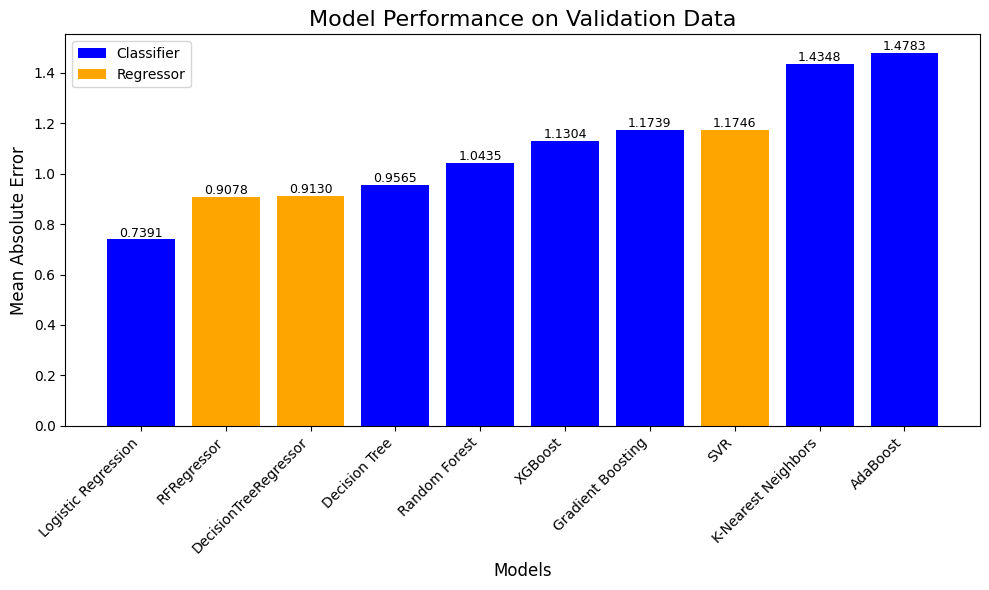

In [ ]:
# All of the models are tested on the new training data
models = initiate_models()

mae_dict = {}
feature_importances = {}

for model_name, model in models.items():
  model.fit(X_train_selected, y_train_a)
  y_pred = model.predict(X_val_selected)
  mae_dict[model_name] = (mean_absolute_error(y_val, y_pred))

  # Extract feature importances if available
  if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_importances[model_name] = pd.DataFrame({
            "Feature": X_train_selected.columns,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

mae_dict = dict(sorted(mae_dict.items(), key=lambda item: item[1]))

print('Best model based on MAE (lasso):' + str(min(mae_dict, key=mae_dict.get)))
plot_model_mae(mae_dict)

In [ ]:
mae_dict

{'Logistic Regression': 0.7391304347826086,
 'RFRegressor': 0.9078260869565217,
 'DecisionTreeRegressor': 0.9130434782608695,
 'Decision Tree': 0.9565217391304348,
 'Random Forest': 1.0434782608695652,
 'XGBoost': 1.1304347826086956,
 'Gradient Boosting': 1.173913043478261,
 'SVR': 1.1746346829361594,
 'K-Nearest Neighbors': 1.434782608695652,
 'AdaBoost': 1.4782608695652173}

Lasso improved
0.7391304347826086


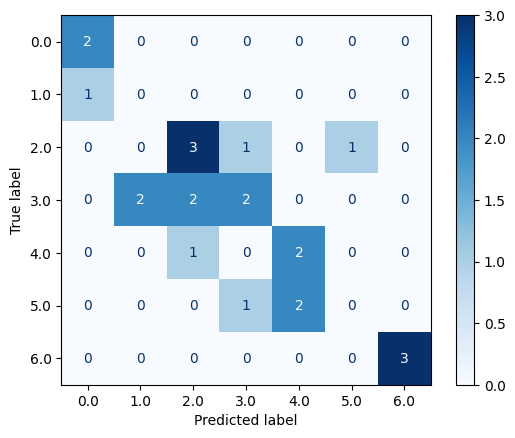

In [ ]:
if mae_dict[min(mae_dict, key=mae_dict.get)] <= best_mae:
  print("Lasso improved")
  best_model = models[min(mae_dict, key=mae_dict.get)]

y_pred = best_model.predict(X_val_selected)
plot_confusion_matrix(y_val, y_pred)

## Testing best model on test data

1.5454545454545454


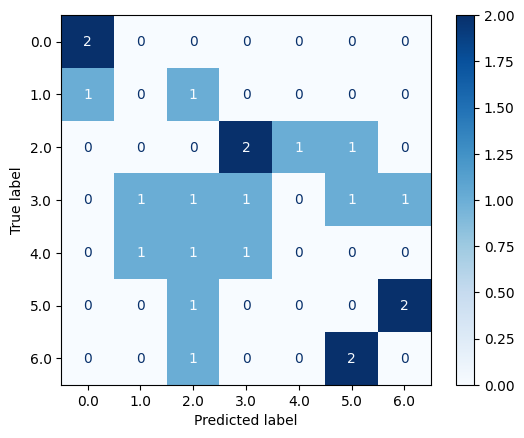

In [ ]:
y_pred = best_model.predict(X_test[selected_features["Feature"]])
plot_confusion_matrix(y_test, y_pred)

# Additional model testing
This did not lead anywhere.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
top_10_features = [
        "Total_activity_week_16",
        "Viewed_lecture_2_materials",
        "Watched",
        "Total_activity_week_17",
]

students['Grade'] = students['Grade'].fillna(-1)
X = students.drop(['Grade', 'Student'], axis=1)
X = students[top_10_features]
y = students['Grade']

# Split the data into training, validation, and test sets
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

models = {
    "Logistic Regression": LogisticRegression(
      max_iter=1000,
      C=0.2,
      random_state=42,
    )
}

metrics_dict = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    metrics_dict[model_name] = {'accuracy': accuracy, 'rmse': rmse}

    print(f"\nModel: {model_name}")
    print("Actual Grades:   ", list(y_test))
    print("Predicted Grades:", list(y_pred))
    print(f"MAE: {mae:.2f}")

for model_name, metrics in metrics_dict.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrics['accuracy'] * 100:.2f}%")
    print(f"  RMSE: {metrics['rmse']:.2f}")

print("\nClassification Report (for last model):")
print(classification_report(y_test, y_pred))

y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
class_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7']

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

SMOTEGA

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
top_10_features = [
        "Feedback count",
        "Total_activity_week_16",
        "Viewed_lecture_2materials",
        "Watched",
        "Total_activity_week_17",
        "Total_activity_week_10"
]

students['Grade'] = students['Grade'].fillna(-1)
X = students.drop(['Grade', 'Student'], axis=1)
X = students[top_10_features]
y = students['Grade']

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

models = {
    "Logistic Regression": LogisticRegression(
      max_iter=1000,
      C=0.2,
      random_state=42,
    )
}

metrics_dict = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    metrics_dict[model_name] = {'accuracy': accuracy, 'rmse': rmse}

    print(f"\nModel: {model_name}")
    print("Actual Grades:   ", list(y_test))
    print("Predicted Grades:", list(y_pred))
    print(f"MAE: {mae:.2f}")

for model_name, metrics in metrics_dict.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrics['accuracy'] * 100:.2f}%")
    print(f"  RMSE: {metrics['rmse']:.2f}")

print("\nClassification Report (for last model):")
print(classification_report(y_test, y_pred))

y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)

class_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7']

plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()